# Building Energy Consumption Forecasting — Batch Model Development

This notebook represents the batch modelling stage of an energy analytics pipeline. The objective is to build a repeatable machine learning workflow that predicts 6-hour building energy consumption using meter readings, building metadata and site-level weather observations.

The final output of this notebook is a saved Spark ML pipeline that can be loaded by the streaming prediction notebook. For that reason, the same feature definitions, time-window logic and target transformation used here are designed to be reproducible during real-time inference.

The modelling target is `consumption_6h`, and the training label is `log1p(consumption_6h)`. This target transformation is used because building energy consumption is highly skewed and contains many zero or low-consumption intervals. Model performance is evaluated using RMSLE, which is consistent with the log-transformed target.



## 1. Spark session setup

The workflow starts by creating a local Spark session for large-scale data processing and model training. The meter dataset is large enough that a Spark-based workflow is more appropriate than loading the full data into pandas.

The Spark configuration is kept conservative for a local machine: limited partitions, controlled memory settings and reduced console progress output. This keeps the notebook stable while still following the same distributed-processing pattern used in production data pipelines.



In [49]:
# ==========================================
# 1. Spark Session Setup
# ==========================================

import os
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark import SparkConf

# Stop any existing Spark session before creating a clean one.
try:
    spark.stop()
except NameError:
    pass
except Exception:
    pass

conf = (
    SparkConf()
    .setAppName("BuildingEnergyPrediction")
    .setMaster("local[4]")
    .set("spark.driver.memory", "8g")
    .set("spark.executor.memory", "8g")
    .set("spark.executor.cores", "2")
    .set("spark.sql.shuffle.partitions", "8")
    .set("spark.default.parallelism", "8")
    .set("spark.sql.files.maxPartitionBytes", str(32 * 1024 * 1024))
    .set("spark.ui.showConsoleProgress", "false")
)

spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print("Spark session created successfully.")
print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)
print("Application name:", spark.sparkContext.appName)

Spark session created successfully.
Spark version: 3.5.0
Spark master: local[4]
Application name: BuildingEnergyPrediction


## 2. Imports and project paths

All libraries and project paths are defined in one place so the notebook can be moved between the project root and the `notebooks/` folder without changing hard-coded paths.

The project structure separates source data, model artifacts and output screenshots. This keeps the repository organised and makes the batch model easy to connect with the downstream streaming notebooks.



In [51]:
# ==========================================
# 2. Imports and Project Paths
# ==========================================

import math
import json
import shutil
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    DoubleType,
    StringType,
    TimestampType
)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
SCREENSHOT_DIR = OUTPUT_DIR / "screenshots"

METERS_PATH = DATA_DIR / "meters.csv"
BUILDINGS_PATH = DATA_DIR / "building_information.csv"
WEATHER_PATH = DATA_DIR / "weather.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Screenshot directory:", SCREENSHOT_DIR)
print("Meters path:", METERS_PATH)
print("Buildings path:", BUILDINGS_PATH)
print("Weather path:", WEATHER_PATH)

for path in [METERS_PATH, BUILDINGS_PATH, WEATHER_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print("All required data files found.")

Project root: /Users/harshithreddy/building-energy-prediction-streaming
Data directory: /Users/harshithreddy/building-energy-prediction-streaming/data
Model directory: /Users/harshithreddy/building-energy-prediction-streaming/models
Screenshot directory: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots
Meters path: /Users/harshithreddy/building-energy-prediction-streaming/data/meters.csv
Buildings path: /Users/harshithreddy/building-energy-prediction-streaming/data/building_information.csv
Weather path: /Users/harshithreddy/building-energy-prediction-streaming/data/weather.csv
All required data files found.


## 3. Load source data

The project uses three source datasets: meter readings, building metadata and weather observations. Meter readings provide the target variable, building metadata provides static building-level features, and weather observations provide site-level environmental features.

Explicit schemas are used when reading the files so identifiers, timestamps and numeric columns are interpreted consistently by Spark. This reduces schema drift and prevents type issues later in the feature engineering and modelling steps.



In [53]:
# ==========================================
# 3. Define Schemas and Load Source Data
# ==========================================

meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("value", DoubleType(), True),
    StructField("row_id", IntegerType(), True)
])

buildings_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", IntegerType(), True),
    StructField("year_built", IntegerType(), True),
    StructField("latent_y", DoubleType(), True),
    StructField("latent_s", DoubleType(), True),
    StructField("latent_r", DoubleType(), True)
])

weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DoubleType(), True),
    StructField("cloud_coverage", DoubleType(), True),
    StructField("dew_temperature", DoubleType(), True),
    StructField("sea_level_pressure", DoubleType(), True),
    StructField("wind_direction", DoubleType(), True),
    StructField("wind_speed", DoubleType(), True)
])

meters_df = (
    spark.read
    .option("header", True)
    .schema(meters_schema)
    .csv(str(METERS_PATH))
)

buildings_df = (
    spark.read
    .option("header", True)
    .schema(buildings_schema)
    .csv(str(BUILDINGS_PATH))
)

weather_df = (
    spark.read
    .option("header", True)
    .schema(weather_schema)
    .csv(str(WEATHER_PATH))
)

print("Raw data loaded successfully.")
print("Meters rows:", meters_df.count())
print("Buildings rows:", buildings_df.count())
print("Weather rows:", weather_df.count())

print("\nMeters schema:")
meters_df.printSchema()

print("\nBuildings schema:")
buildings_df.printSchema()

print("\nWeather schema:")
weather_df.printSchema()

Raw data loaded successfully.
Meters rows: 13825018
Buildings rows: 1000
Weather rows: 139773

Meters schema:
root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- row_id: integer (nullable = true)


Buildings schema:
root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)


Weather schema:
root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = tru

## 4. Clean meter readings

The raw meter file stores timestamps in `ts` and energy readings in `value`. These fields are standardised into `timestamp` and `meter_reading` so the rest of the pipeline can use clear modelling names.

Rows with missing timestamps, missing building IDs, missing readings or negative readings are removed. This ensures that the model target is built only from valid meter observations.



In [55]:
# ==========================================
# 4. Clean Meter Readings
# ==========================================

print("Meters columns:", meters_df.columns)

meters_clean = (
    meters_df
    .withColumn("timestamp", F.to_timestamp(F.col("ts")))
    .withColumn("building_id", F.col("building_id").cast("int"))
    .withColumn("meter_reading", F.col("value").cast("double"))
    .filter(F.col("timestamp").isNotNull())
    .filter(F.col("building_id").isNotNull())
    .filter(F.col("meter_reading").isNotNull())
    .filter(F.col("meter_reading") >= 0)
    .select(
        "building_id",
        "timestamp",
        "meter_reading"
    )
    .cache()
)

print("Meter data cleaned successfully.")
print("Rows after cleaning:", meters_clean.count())

meters_clean.orderBy("building_id", "timestamp").show(10, truncate=False)

Meters columns: ['building_id', 'meter_type', 'ts', 'value', 'row_id']
Meter data cleaned successfully.
Rows after cleaning: 13825018
+-----------+-------------------+-------------+
|building_id|timestamp          |meter_reading|
+-----------+-------------------+-------------+
|0          |2022-01-01 00:00:00|0.0          |
|0          |2022-01-01 01:00:00|0.0          |
|0          |2022-01-01 02:00:00|0.0          |
|0          |2022-01-01 03:00:00|0.0          |
|0          |2022-01-01 04:00:00|0.0          |
|0          |2022-01-01 05:00:00|0.0          |
|0          |2022-01-01 06:00:00|0.0          |
|0          |2022-01-01 07:00:00|0.0          |
|0          |2022-01-01 08:00:00|0.0          |
|0          |2022-01-01 09:00:00|0.0          |
+-----------+-------------------+-------------+
only showing top 10 rows



## 5. Aggregate meter readings into 6-hour windows

Meter readings are aggregated into 6-hour building-level consumption totals. This creates the main prediction target for the model: one row per `building_id + window_start`.

The 6-hour grain was selected because it is detailed enough to capture daily consumption patterns while still being practical for streaming prediction. The same windowing logic is reused later when incoming weather events are processed in the streaming pipeline.



In [57]:
# ==========================================
# 5. Aggregate Meter Readings into 6-Hour Windows
# ==========================================

meters_agg = (
    meters_clean
    .withColumn("date", F.to_date("timestamp"))
    .withColumn("hour", F.hour("timestamp"))
    .withColumn("bucket", F.floor(F.col("hour") / F.lit(6)).cast("int"))
    .withColumn("bucket_start_hour", F.col("bucket") * 6)
    .withColumn(
        "window_start",
        F.to_timestamp(
            F.concat(
                F.col("date").cast("string"),
                F.lit(" "),
                F.lpad(F.col("bucket_start_hour").cast("string"), 2, "0"),
                F.lit(":00:00")
            )
        )
    )
    .groupBy("building_id", "window_start", "bucket")
    .agg(F.sum("meter_reading").alias("consumption_6h"))
    .withColumn(
        "six_hour_block",
        F.when(F.col("bucket") == 0, "00:00-05:59")
         .when(F.col("bucket") == 1, "06:00-11:59")
         .when(F.col("bucket") == 2, "12:00-17:59")
         .otherwise("18:00-23:59")
    )
    .select(
        "building_id",
        "window_start",
        "six_hour_block",
        "consumption_6h"
    )
    .filter(F.col("consumption_6h").isNotNull())
    .filter(F.col("consumption_6h") >= 0)
    .cache()
)

print("Meter readings aggregated into 6-hour windows.")
print("Rows:", meters_agg.count())
print("Distinct buildings:", meters_agg.select("building_id").distinct().count())

print("\nSample aggregated meter data:")
meters_agg.orderBy("building_id", "window_start").show(10, truncate=False)

print("\nCount by 6-hour block:")
meters_agg.groupBy("six_hour_block").count().orderBy("six_hour_block").show(truncate=False)

Meter readings aggregated into 6-hour windows.
Rows: 1423715
Distinct buildings: 1000

Sample aggregated meter data:
+-----------+-------------------+--------------+--------------+
|building_id|window_start       |six_hour_block|consumption_6h|
+-----------+-------------------+--------------+--------------+
|0          |2022-01-01 00:00:00|00:00-05:59   |0.0           |
|0          |2022-01-01 06:00:00|06:00-11:59   |0.0           |
|0          |2022-01-01 12:00:00|12:00-17:59   |0.0           |
|0          |2022-01-01 18:00:00|18:00-23:59   |0.0           |
|0          |2022-01-02 00:00:00|00:00-05:59   |0.0           |
|0          |2022-01-02 06:00:00|06:00-11:59   |0.0           |
|0          |2022-01-02 12:00:00|12:00-17:59   |0.0           |
|0          |2022-01-02 18:00:00|18:00-23:59   |0.0           |
|0          |2022-01-03 00:00:00|00:00-05:59   |0.0           |
|0          |2022-01-03 06:00:00|06:00-11:59   |0.0           |
+-----------+-------------------+--------------+---

## 6. Clean building metadata

Building metadata is prepared as the static feature table for the model. The key fields are building ID, site ID, primary building use, square footage, floor count, year built and latent building descriptors.

Valid building records are retained and numeric fields are cast to the correct types. Missing building-use values are labelled as `Unknown` so that categorical encoding can handle them consistently during training and streaming inference.



In [59]:
# ==========================================
# 6. Clean Building Metadata
# ==========================================

required_building_cols = [
    "building_id",
    "site_id",
    "primary_use",
    "square_feet"
]

missing_building_cols = [
    col_name for col_name in required_building_cols
    if col_name not in buildings_df.columns
]

if missing_building_cols:
    raise ValueError(f"Missing building columns: {missing_building_cols}")

optional_numeric_building_cols = [
    "floor_count",
    "year_built",
    "latent_y",
    "latent_s",
    "latent_r"
]

for col_name in optional_numeric_building_cols:
    if col_name not in buildings_df.columns:
        buildings_df = buildings_df.withColumn(col_name, F.lit(None).cast("double"))

buildings_clean = (
    buildings_df
    .withColumn("building_id", F.col("building_id").cast("int"))
    .withColumn("site_id", F.col("site_id").cast("int"))
    .withColumn("primary_use", F.coalesce(F.col("primary_use"), F.lit("Unknown")))
    .withColumn("square_feet", F.col("square_feet").cast("double"))
    .withColumn("floor_count", F.col("floor_count").cast("double"))
    .withColumn("year_built", F.col("year_built").cast("double"))
    .withColumn("latent_y", F.col("latent_y").cast("double"))
    .withColumn("latent_s", F.col("latent_s").cast("double"))
    .withColumn("latent_r", F.col("latent_r").cast("double"))
    .filter(F.col("building_id").isNotNull())
    .filter(F.col("site_id").isNotNull())
    .filter(F.col("square_feet").isNotNull())
    .filter(F.col("square_feet") > 0)
    .dropDuplicates(["building_id"])
    .select(
        "building_id",
        "site_id",
        "primary_use",
        "square_feet",
        "floor_count",
        "year_built",
        "latent_y",
        "latent_s",
        "latent_r"
    )
    .cache()
)

print("Building metadata cleaned successfully.")
print("Rows:", buildings_clean.count())
print("Distinct sites:", buildings_clean.select("site_id").distinct().count())

buildings_clean.orderBy("building_id").show(10, truncate=False)

Building metadata cleaned successfully.
Rows: 1000
Distinct sites: 16
+-----------+-------+-------------+-----------+-----------+----------+--------+---------+--------+
|building_id|site_id|primary_use  |square_feet|floor_count|year_built|latent_y|latent_s |latent_r|
+-----------+-------+-------------+-----------+-----------+----------+--------+---------+--------+
|0          |0      |Education    |7432.0     |1.0        |2015.0    |15.0    |3.8711057|0.0     |
|1          |0      |Education    |2720.0     |1.0        |2011.0    |11.0    |3.434569 |0.0     |
|2          |0      |Education    |5376.0     |1.0        |1998.0    |2.0     |3.7304592|0.0     |
|3          |0      |Education    |23685.0    |1.0        |2009.0    |9.0     |4.3744736|1.0     |
|5          |0      |Education    |8000.0     |1.0        |2007.0    |7.0     |3.90309  |1.0     |
|6          |0      |Residential  |27926.0    |1.0        |1988.0    |12.0    |4.4460087|1.0     |
|8          |0      |Education    |6080

## 7. Prepare weather features

Weather observations are recorded at site level, while the prediction target is calculated at building level. To make the datasets compatible, weather records are cleaned and aggregated to the same 6-hour `site_id + window_start` grain used by the meter target.

The resulting weather features summarise air temperature, dew temperature, pressure, wind speed, cloud coverage and wind direction for each site and time window. This allows each building to inherit the weather conditions from its site during the same 6-hour interval.



In [61]:
# ==========================================
# 7. Clean and Aggregate Weather Data
# ==========================================

weather_numeric_cols = [
    "air_temperature",
    "dew_temperature",
    "sea_level_pressure",
    "wind_speed",
    "cloud_coverage",
    "wind_direction"
]

for col_name in weather_numeric_cols:
    if col_name not in weather_df.columns:
        weather_df = weather_df.withColumn(col_name, F.lit(None).cast("double"))

weather_clean = (
    weather_df
    .withColumn("site_id", F.col("site_id").cast("int"))
    .withColumn("timestamp", F.to_timestamp(F.col("timestamp")))
)

for col_name in weather_numeric_cols:
    weather_clean = weather_clean.withColumn(col_name, F.col(col_name).cast("double"))

weather_clean = (
    weather_clean
    .filter(F.col("site_id").isNotNull())
    .filter(F.col("timestamp").isNotNull())
    .select("site_id", "timestamp", *weather_numeric_cols)
    .cache()
)

weather_6h = (
    weather_clean
    .withColumn("date", F.to_date("timestamp"))
    .withColumn("hour", F.hour("timestamp"))
    .withColumn("bucket", F.floor(F.col("hour") / F.lit(6)).cast("int"))
    .withColumn("bucket_start_hour", F.col("bucket") * 6)
    .withColumn(
        "window_start",
        F.to_timestamp(
            F.concat(
                F.col("date").cast("string"),
                F.lit(" "),
                F.lpad(F.col("bucket_start_hour").cast("string"), 2, "0"),
                F.lit(":00:00")
            )
        )
    )
    .groupBy("site_id", "window_start", "bucket")
    .agg(
        F.avg("air_temperature").alias("air_temperature_6h"),
        F.avg("dew_temperature").alias("dew_temperature_6h"),
        F.avg("sea_level_pressure").alias("sea_level_pressure_6h"),
        F.avg("wind_speed").alias("wind_speed_6h"),
        F.avg("cloud_coverage").alias("cloud_coverage_6h"),
        F.avg("wind_direction").alias("wind_direction_6h")
    )
    .withColumn(
        "six_hour_block",
        F.when(F.col("bucket") == 0, "00:00-05:59")
         .when(F.col("bucket") == 1, "06:00-11:59")
         .when(F.col("bucket") == 2, "12:00-17:59")
         .otherwise("18:00-23:59")
    )
    .select(
        "site_id",
        "window_start",
        "six_hour_block",
        "air_temperature_6h",
        "dew_temperature_6h",
        "sea_level_pressure_6h",
        "wind_speed_6h",
        "cloud_coverage_6h",
        "wind_direction_6h"
    )
    .cache()
)

print("Weather data cleaned and aggregated into 6-hour windows.")
print("Weather rows after cleaning:", weather_clean.count())
print("Weather 6-hour rows:", weather_6h.count())

weather_6h.orderBy("site_id", "window_start").show(10, truncate=False)

Weather data cleaned and aggregated into 6-hour windows.
Weather rows after cleaning: 139773
Weather 6-hour rows: 23332
+-------+-------------------+--------------+------------------+------------------+---------------------+------------------+-----------------+------------------+
|site_id|window_start       |six_hour_block|air_temperature_6h|dew_temperature_6h|sea_level_pressure_6h|wind_speed_6h     |cloud_coverage_6h|wind_direction_6h |
+-------+-------------------+--------------+------------------+------------------+---------------------+------------------+-----------------+------------------+
|0      |2022-01-01 00:00:00|00:00-05:59   |22.11666666666667 |20.36666666666667 |1020.0400000000002   |0.6833333333333332|3.0              |53.333333333333336|
|0      |2022-01-01 06:00:00|06:00-11:59   |20.933333333333334|20.566666666666666|1018.7666666666665   |0.5               |6.0              |83.33333333333333 |
|0      |2022-01-01 12:00:00|12:00-17:59   |22.88333333333333 |20.283333333

## 8. Create the final modelling table

The final modelling table combines the aggregated meter target, building metadata and 6-hour weather features. The final grain is `site_id + building_id + window_start`, which is the correct level for both training and later evaluation.

Additional features are engineered to capture building scale, building age, seasonal effects, wind direction and recurring time patterns. Keeping this feature logic explicit makes it easier to reproduce the same inputs in the streaming prediction notebook.



In [63]:
# ==========================================
# 8. Create Final Modelling Table
# ==========================================

REFERENCE_YEAR = 2025

feature_df = (
    meters_agg
    .join(buildings_clean, on="building_id", how="inner")
    .join(
        weather_6h.select(
            "site_id",
            "window_start",
            "air_temperature_6h",
            "dew_temperature_6h",
            "sea_level_pressure_6h",
            "wind_speed_6h",
            "cloud_coverage_6h",
            "wind_direction_6h"
        ),
        on=["site_id", "window_start"],
        how="left"
    )
)

features_raw_df = (
    feature_df
    .withColumn("log_square_feet", F.log1p(F.col("square_feet")))
    .withColumn(
        "building_age",
        F.when(
            F.col("year_built").isNotNull(),
            F.lit(REFERENCE_YEAR) - F.col("year_built")
        ).otherwise(None)
    )
    .withColumn("month", F.month("window_start"))
    .withColumn(
        "season_flag",
        F.when(F.col("month").isin([1, 2, 6, 7, 8, 12]), F.lit("peak"))
         .otherwise(F.lit("off_peak"))
    )
    .withColumn(
        "wind_direction_radians",
        F.col("wind_direction_6h") * F.lit(math.pi / 180.0)
    )
    .withColumn("wind_dir_sin", F.sin("wind_direction_radians"))
    .withColumn("wind_dir_cos", F.cos("wind_direction_radians"))
    .withColumn(
        "log_consumption_6h",
        F.log1p(F.greatest(F.col("consumption_6h"), F.lit(0.0)))
    )
    .select(
        "site_id",
        "building_id",
        "window_start",
        "consumption_6h",
        "log_consumption_6h",
        "primary_use",
        "season_flag",
        "log_square_feet",
        "floor_count",
        "building_age",
        "air_temperature_6h",
        "dew_temperature_6h",
        "sea_level_pressure_6h",
        "wind_speed_6h",
        "cloud_coverage_6h",
        "wind_dir_sin",
        "wind_dir_cos",
        "latent_y",
        "latent_s",
        "latent_r"
    )
    .filter(F.col("consumption_6h").isNotNull())
    .filter(F.col("consumption_6h") >= 0)
    .cache()
)

print("Final modelling table created.")
print("Rows:", features_raw_df.count())
print("Distinct buildings:", features_raw_df.select("building_id").distinct().count())
print("Distinct sites:", features_raw_df.select("site_id").distinct().count())
print("log_consumption_6h exists:", "log_consumption_6h" in features_raw_df.columns)

features_raw_df.orderBy("building_id", "window_start").show(10, truncate=False)

Final modelling table created.
Rows: 1423715
Distinct buildings: 1000
Distinct sites: 16
log_consumption_6h exists: True
+-------+-----------+-------------------+--------------+------------------+-----------+-----------+-----------------+-----------+------------+------------------+------------------+---------------------+------------------+-----------------+--------------------+-------------------+--------+---------+--------+
|site_id|building_id|window_start       |consumption_6h|log_consumption_6h|primary_use|season_flag|log_square_feet  |floor_count|building_age|air_temperature_6h|dew_temperature_6h|sea_level_pressure_6h|wind_speed_6h     |cloud_coverage_6h|wind_dir_sin        |wind_dir_cos       |latent_y|latent_s |latent_r|
+-------+-----------+-------------------+--------------+------------------+-----------+-----------+-----------------+-----------+------------+------------------+------------------+---------------------+------------------+-----------------+--------------------+-

## 9. Data quality checks

Before modelling, the final feature table is checked for missing values, zero-consumption rows and target distribution behaviour. These checks help identify whether the model will need imputation, target transformation or careful evaluation.

The zero-consumption rate and summary statistics are especially important for this problem because energy data is usually skewed. A small number of high-consumption intervals can otherwise dominate model training and visual interpretation.



In [65]:
# ==========================================
# 9. Data Quality Checks
# ==========================================

row_count = features_raw_df.count()

missing_summary = []
for col_name in features_raw_df.columns:
    missing_count = features_raw_df.filter(F.col(col_name).isNull()).count()
    missing_summary.append((col_name, missing_count, missing_count / row_count if row_count else 0.0))

missing_summary_df = pd.DataFrame(
    missing_summary,
    columns=["column", "missing_count", "missing_rate"]
).sort_values("missing_count", ascending=False)

print("Missing value summary:")
display(missing_summary_df)

zero_count = features_raw_df.filter(F.col("consumption_6h") == 0).count()
zero_rate = zero_count / row_count if row_count else 0.0

print(f"Total rows: {row_count}")
print(f"Zero consumption rows: {zero_count}")
print(f"Zero consumption rate: {zero_rate:.2%}")

print("\nTarget summary:")
features_raw_df.select("consumption_6h", "log_consumption_6h").summary().show(truncate=False)

Missing value summary:


,column,missing_count,missing_rate
14,cloud_coverage_6h,215226,0.151172
12,sea_level_pressure_6h,89474,0.062845
16,wind_dir_cos,2615,0.001837
15,wind_dir_sin,2615,0.001837
10,air_temperature_6h,1245,0.000874
13,wind_speed_6h,1245,0.000874
11,dew_temperature_6h,1245,0.000874
1,building_id,0,0.000000
18,latent_s,0,0.000000
17,latent_y,0,0.000000


Total rows: 1423715
Zero consumption rows: 53081
Zero consumption rate: 3.73%

Target summary:
+-------+------------------+------------------+
|summary|consumption_6h    |log_consumption_6h|
+-------+------------------+------------------+
|count  |1423715           |1423715           |
|mean   |27402.506595663737|6.206647476823462 |
|stddev |1404121.112603554 |2.356616948476964 |
|min    |0.0               |0.0               |
|25%    |134.9             |4.911919321157098 |
|50%    |575.4065          |6.3568131409528315|
|75%    |2543.6699999999996|7.841756254565471 |
|max    |1.25457627725E8   |18.64747863980863 |
+-------+------------------+------------------+



## 10. Exploratory data visualisation

The visual analysis focuses on patterns that directly affect the modelling decision: target skew, time-of-day behaviour, building-use differences, building size effects and temperature relationships.

The plots are created from aggregated or sampled Spark outputs so the notebook remains efficient. Each visualisation uses the same modelling grain where appropriate, avoiding misleading charts caused by mixing building-level, site-level and daily totals.



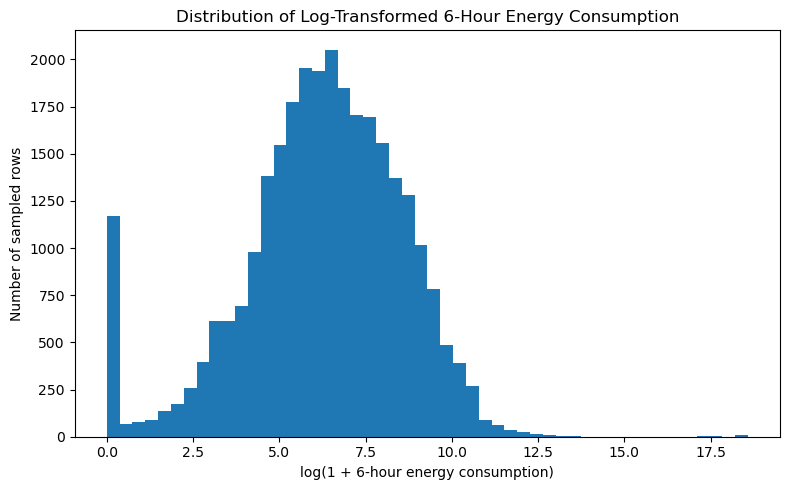

Plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/eda_log_consumption_distribution.png


In [67]:
# ==========================================
# 10.1 EDA Plot: Distribution of 6-Hour Energy Consumption
# ==========================================

plot_distribution_df = (
    features_raw_df
    .select("consumption_6h", "log_consumption_6h")
    .filter(F.col("consumption_6h").isNotNull())
    .sample(False, 0.02, seed=42)
    .limit(50000)
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.hist(plot_distribution_df["log_consumption_6h"], bins=50)
plt.xlabel("log(1 + 6-hour energy consumption)")
plt.ylabel("Number of sampled rows")
plt.title("Distribution of Log-Transformed 6-Hour Energy Consumption")
plt.tight_layout()

plot_path = SCREENSHOT_DIR / "eda_log_consumption_distribution.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)

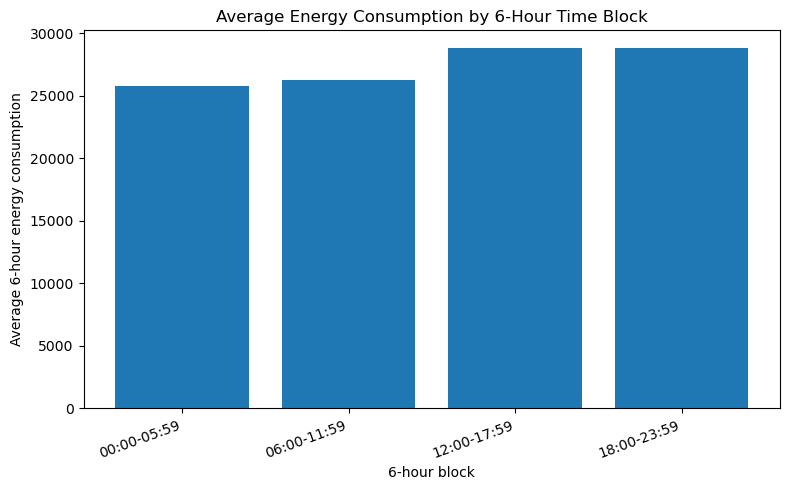

Plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/eda_consumption_by_6h_block.png


In [68]:
# ==========================================
# 10.2 EDA Plot: Average Consumption by 6-Hour Block
# ==========================================

block_summary_df = (
    meters_agg
    .groupBy("six_hour_block")
    .agg(F.avg("consumption_6h").alias("average_consumption_6h"))
    .orderBy("six_hour_block")
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(
    block_summary_df["six_hour_block"],
    block_summary_df["average_consumption_6h"]
)
plt.xlabel("6-hour block")
plt.ylabel("Average 6-hour energy consumption")
plt.title("Average Energy Consumption by 6-Hour Time Block")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plot_path = SCREENSHOT_DIR / "eda_consumption_by_6h_block.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)

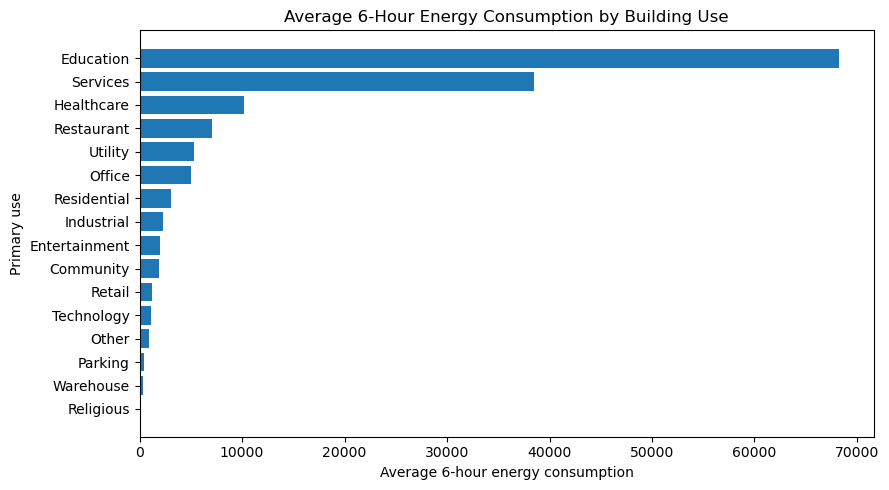

Plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/eda_consumption_by_primary_use.png


In [69]:
# ==========================================
# 10.3 EDA Plot: Average Consumption by Building Use
# ==========================================

primary_use_summary_df = (
    feature_df
    .filter(F.col("primary_use").isNotNull())
    .groupBy("primary_use")
    .agg(F.avg("consumption_6h").alias("average_consumption_6h"))
    .orderBy(F.desc("average_consumption_6h"))
    .toPandas()
)

plt.figure(figsize=(9, 5))
plt.barh(
    primary_use_summary_df["primary_use"],
    primary_use_summary_df["average_consumption_6h"]
)
plt.xlabel("Average 6-hour energy consumption")
plt.ylabel("Primary use")
plt.title("Average 6-Hour Energy Consumption by Building Use")
plt.gca().invert_yaxis()
plt.tight_layout()

plot_path = SCREENSHOT_DIR / "eda_consumption_by_primary_use.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)

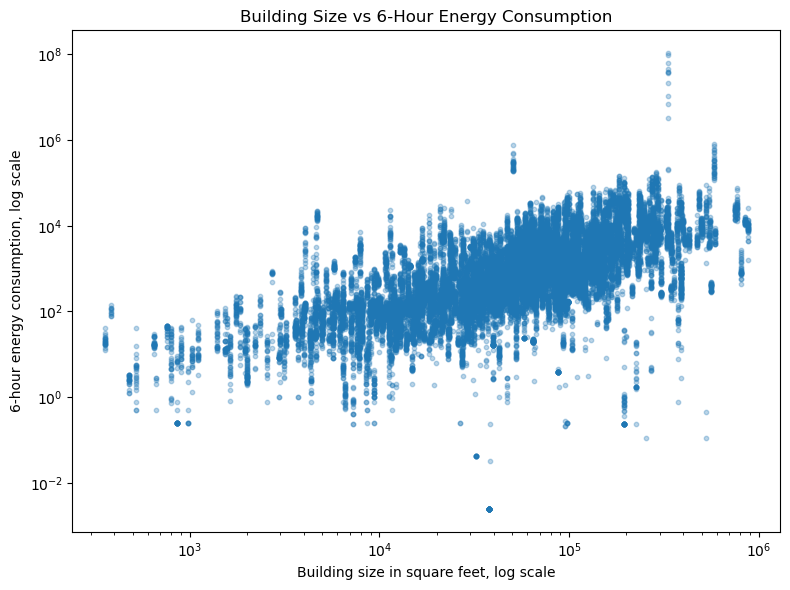

Plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/eda_building_size_vs_consumption.png


In [70]:
# ==========================================
# 10.4 EDA Plot: Building Size vs Energy Consumption
# ==========================================

plot_size_df = (
    feature_df
    .select("square_feet", "consumption_6h")
    .filter(F.col("square_feet").isNotNull())
    .filter(F.col("consumption_6h").isNotNull())
    .filter(F.col("square_feet") > 0)
    .filter(F.col("consumption_6h") > 0)
    .sample(False, 0.02, seed=42)
    .limit(50000)
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_size_df["square_feet"],
    plot_size_df["consumption_6h"],
    alpha=0.3,
    s=10
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Building size in square feet, log scale")
plt.ylabel("6-hour energy consumption, log scale")
plt.title("Building Size vs 6-Hour Energy Consumption")
plt.tight_layout()

plot_path = SCREENSHOT_DIR / "eda_building_size_vs_consumption.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)

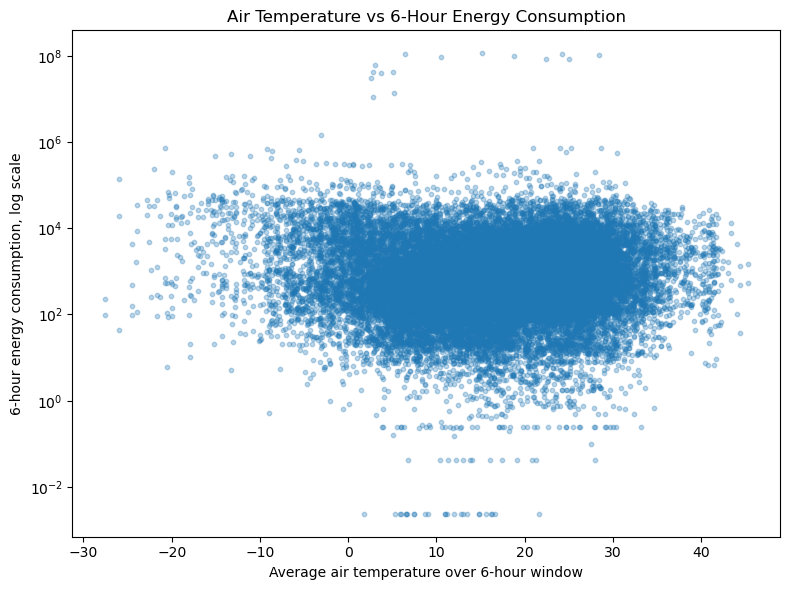

Plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/eda_temperature_vs_consumption.png


In [71]:
# ==========================================
# 10.5 EDA Plot: Air Temperature vs Energy Consumption
# ==========================================

plot_weather_df = (
    features_raw_df
    .select("air_temperature_6h", "consumption_6h")
    .filter(F.col("air_temperature_6h").isNotNull())
    .filter(F.col("consumption_6h").isNotNull())
    .filter(F.col("consumption_6h") > 0)
    .sample(False, 0.02, seed=42)
    .limit(50000)
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_weather_df["air_temperature_6h"],
    plot_weather_df["consumption_6h"],
    alpha=0.3,
    s=10
)
plt.yscale("log")
plt.xlabel("Average air temperature over 6-hour window")
plt.ylabel("6-hour energy consumption, log scale")
plt.title("Air Temperature vs 6-Hour Energy Consumption")
plt.tight_layout()

plot_path = SCREENSHOT_DIR / "eda_temperature_vs_consumption.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)

## 11. Machine learning feature pipeline

A Spark ML pipeline is used to keep preprocessing and modelling in one reusable object. This is important because the saved model will later be loaded by the streaming prediction notebook and applied to new records.

Categorical variables are indexed and one-hot encoded. Numeric variables are imputed, assembled and scaled. The model is trained on `log_consumption_6h`, which represents `log1p(consumption_6h)`.



In [73]:
# ==========================================
# 11. Define Machine Learning Pipeline
# ==========================================

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    Imputer,
    VectorAssembler,
    StandardScaler
)
from pyspark.ml.regression import RandomForestRegressor

LABEL_COL = "log_consumption_6h"

categorical_cols = [
    "primary_use",
    "season_flag"
]

numeric_cols = [
    "log_square_feet",
    "floor_count",
    "building_age",
    "air_temperature_6h",
    "dew_temperature_6h",
    "sea_level_pressure_6h",
    "wind_speed_6h",
    "cloud_coverage_6h",
    "wind_dir_sin",
    "wind_dir_cos",
    "latent_y",
    "latent_s",
    "latent_r"
]

indexers = [
    StringIndexer(
        inputCol=col_name,
        outputCol=f"{col_name}_idx",
        handleInvalid="keep"
    )
    for col_name in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[f"{col_name}_idx" for col_name in categorical_cols],
    outputCols=[f"{col_name}_vec" for col_name in categorical_cols],
    handleInvalid="keep",
    dropLast=False
)

numeric_imputed_cols = [f"{col_name}_imp" for col_name in numeric_cols]

numeric_imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=numeric_imputed_cols,
    strategy="mean"
)

numeric_assembler = VectorAssembler(
    inputCols=numeric_imputed_cols,
    outputCol="numeric_features",
    handleInvalid="keep"
)

numeric_scaler = StandardScaler(
    inputCol="numeric_features",
    outputCol="numeric_scaled",
    withMean=True,
    withStd=True
)

final_assembler = VectorAssembler(
    inputCols=[f"{col_name}_vec" for col_name in categorical_cols] + ["numeric_scaled"],
    outputCol="features",
    handleInvalid="keep"
)

preprocessing_stages = (
    indexers
    + [encoder]
    + [numeric_imputer, numeric_assembler, numeric_scaler, final_assembler]
)

print("Machine learning preprocessing pipeline created.")
print("Target column:", LABEL_COL)
print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

Machine learning preprocessing pipeline created.
Target column: log_consumption_6h
Categorical features: ['primary_use', 'season_flag']
Numeric features: ['log_square_feet', 'floor_count', 'building_age', 'air_temperature_6h', 'dew_temperature_6h', 'sea_level_pressure_6h', 'wind_speed_6h', 'cloud_coverage_6h', 'wind_dir_sin', 'wind_dir_cos', 'latent_y', 'latent_s', 'latent_r']


## 12. Train/test split

The final modelling table is sampled and split into training and testing sets using a fixed random seed. Sampling keeps the notebook runnable on a local machine while still allowing the model to learn from a meaningful subset of the data.

The test set is held out from training and used only for model evaluation. This gives a cleaner estimate of how the model performs on unseen 6-hour building intervals.



In [75]:
# ==========================================
# 12. Prepare Training and Testing Data
# ==========================================

from pyspark import StorageLevel

SAMPLE_FRACTION = 0.10
RANDOM_SEED = 2025

model_input_df = (
    features_raw_df
    .filter(F.col(LABEL_COL).isNotNull())
    .persist(StorageLevel.MEMORY_AND_DISK)
)

data_for_ml = (
    model_input_df
    .sample(
        withReplacement=False,
        fraction=SAMPLE_FRACTION,
        seed=RANDOM_SEED
    )
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print("Sample fraction:", SAMPLE_FRACTION)
print("Sampled rows:", data_for_ml.count())

train_df, test_df = data_for_ml.randomSplit([0.8, 0.2], seed=RANDOM_SEED)

train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df = test_df.persist(StorageLevel.MEMORY_AND_DISK)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())
print("log_consumption_6h in train_df:", "log_consumption_6h" in train_df.columns)
print("log_consumption_6h in test_df:", "log_consumption_6h" in test_df.columns)

Sample fraction: 0.1
Sampled rows: 142530
Training rows: 114080
Testing rows: 28450
log_consumption_6h in train_df: True
log_consumption_6h in test_df: True


## 13. Baseline Random Forest model

A baseline Random Forest model is trained first to create a reference score. The baseline uses the full preprocessing pipeline, so its evaluation reflects the complete modelling workflow rather than the regressor alone.

This baseline provides a practical benchmark before training the final model with stronger settings. It also confirms that the feature table, target transformation and Spark ML pipeline are working correctly.



In [77]:
# ==========================================
# 13. Train Baseline Random Forest Model
# ==========================================

baseline_rf = RandomForestRegressor(
    labelCol=LABEL_COL,
    featuresCol="features",
    numTrees=50,
    maxDepth=10,
    maxBins=32,
    subsamplingRate=0.7,
    minInstancesPerNode=5,
    featureSubsetStrategy="auto",
    seed=42
)

baseline_rf_pipeline = Pipeline(
    stages=preprocessing_stages + [baseline_rf]
)

print("Training baseline Random Forest model...")

start_time = time.time()
baseline_rf_model = baseline_rf_pipeline.fit(train_df)
baseline_training_time = time.time() - start_time

print(f"Baseline Random Forest training completed in {baseline_training_time:.1f} seconds")

Training baseline Random Forest model...
Baseline Random Forest training completed in 21.4 seconds


## 14. Baseline evaluation

The baseline model is evaluated using RMSLE. Because the model predicts `log1p(consumption_6h)`, RMSE in log space is equivalent to RMSLE on the original target.

RMSLE is suitable for this project because it reduces the effect of very large consumption values and focuses on proportional error. This is more useful than raw RMSE when buildings have very different consumption scales.



In [79]:
# ==========================================
# 14. Evaluate Baseline Model
# ==========================================

def calculate_rmsle_from_log_prediction(pred_df, label_col, prediction_log_col):
    return (
        pred_df
        .withColumn(
            "squared_log_error",
            F.pow(F.col(prediction_log_col) - F.col(label_col), 2)
        )
        .agg(F.sqrt(F.mean("squared_log_error")).alias("rmsle"))
        .first()["rmsle"]
    )

baseline_pred = (
    baseline_rf_model
    .transform(test_df)
    .withColumn("prediction_log", F.greatest(F.col("prediction"), F.lit(0.0)))
    .withColumn("predicted_consumption", F.expm1(F.col("prediction_log")))
    .select(
        "site_id",
        "building_id",
        "window_start",
        F.col("consumption_6h").alias("actual_consumption"),
        "log_consumption_6h",
        "prediction_log",
        "predicted_consumption"
    )
    .cache()
)

baseline_rmsle = calculate_rmsle_from_log_prediction(
    pred_df=baseline_pred,
    label_col="log_consumption_6h",
    prediction_log_col="prediction_log"
)

print(f"Baseline Random Forest RMSLE: {baseline_rmsle:.5f}")

baseline_pred.orderBy("building_id", "window_start").show(10, truncate=False)

Baseline Random Forest RMSLE: 1.32390
+-------+-----------+-------------------+------------------+------------------+------------------+---------------------+
|site_id|building_id|window_start       |actual_consumption|log_consumption_6h|prediction_log    |predicted_consumption|
+-------+-----------+-------------------+------------------+------------------+------------------+---------------------+
|0      |0          |2022-01-06 18:00:00|0.0               |0.0               |2.791759111143467 |15.309685130506349   |
|0      |0          |2022-02-21 12:00:00|0.0               |0.0               |3.1238767630880697|21.734344691509676   |
|0      |0          |2022-03-03 18:00:00|0.0               |0.0               |3.2884874075532617|25.80229203498294    |
|0      |0          |2022-03-27 18:00:00|0.0               |0.0               |4.597394591575162 |98.22545573214765    |
|0      |0          |2022-03-28 06:00:00|0.0               |0.0               |4.092479855901917 |58.88822186987077

## 15. Final Random Forest model

The final Random Forest model increases model capacity while staying within local Spark memory limits. The chosen settings are intended to improve accuracy without making the notebook unstable or excessively slow.

This trained pipeline is the production artifact for the rest of the project. Once saved, the streaming prediction notebook can load it and apply the same preprocessing and prediction logic to incoming Kafka weather events.



In [81]:
# ==========================================
# 15. Train Final Log-Target Random Forest Model
# ==========================================

FINAL_NUM_TREES = 80
FINAL_MAX_DEPTH = 12
FINAL_MAX_BINS = 32

final_rf = RandomForestRegressor(
    labelCol=LABEL_COL,
    featuresCol="features",
    numTrees=FINAL_NUM_TREES,
    maxDepth=FINAL_MAX_DEPTH,
    maxBins=FINAL_MAX_BINS,
    subsamplingRate=0.7,
    minInstancesPerNode=5,
    featureSubsetStrategy="auto",
    seed=42
)

final_rf_pipeline = Pipeline(
    stages=preprocessing_stages + [final_rf]
)

print("Training final log-target Random Forest model...")
print("numTrees:", FINAL_NUM_TREES)
print("maxDepth:", FINAL_MAX_DEPTH)
print("maxBins:", FINAL_MAX_BINS)

start_time = time.time()
final_rf_model = final_rf_pipeline.fit(train_df)
final_training_time = time.time() - start_time

print(f"Final model training completed in {final_training_time:.1f} seconds")

Training final log-target Random Forest model...
numTrees: 80
maxDepth: 12
maxBins: 32
Final model training completed in 70.3 seconds


In [82]:
# ==========================================
# 16. Evaluate Final Model
# ==========================================

final_rf_pred = (
    final_rf_model
    .transform(test_df)
    .withColumn("prediction_log", F.greatest(F.col("prediction"), F.lit(0.0)))
    .withColumn("predicted_consumption", F.expm1(F.col("prediction_log")))
    .select(
        "site_id",
        "building_id",
        "window_start",
        F.col("consumption_6h").alias("actual_consumption"),
        "log_consumption_6h",
        "prediction_log",
        "predicted_consumption"
    )
    .cache()
)

final_rf_rmsle = calculate_rmsle_from_log_prediction(
    pred_df=final_rf_pred,
    label_col="log_consumption_6h",
    prediction_log_col="prediction_log"
)

print(f"Final Log-Target Random Forest RMSLE: {final_rf_rmsle:.5f}")

print("\nFinal model prediction sample:")
final_rf_pred.orderBy("building_id", "window_start").show(10, truncate=False)

Final Log-Target Random Forest RMSLE: 1.21121

Final model prediction sample:
+-------+-----------+-------------------+------------------+------------------+------------------+---------------------+
|site_id|building_id|window_start       |actual_consumption|log_consumption_6h|prediction_log    |predicted_consumption|
+-------+-----------+-------------------+------------------+------------------+------------------+---------------------+
|0      |0          |2022-01-06 18:00:00|0.0               |0.0               |2.5596441731828605|11.931215223663      |
|0      |0          |2022-02-21 12:00:00|0.0               |0.0               |2.6794343830610066|13.576846052665944   |
|0      |0          |2022-03-03 18:00:00|0.0               |0.0               |2.9198687424978362|17.538853936380598   |
|0      |0          |2022-03-27 18:00:00|0.0               |0.0               |4.622235852425051 |100.72121168274828   |
|0      |0          |2022-03-28 06:00:00|0.0               |0.0            

## 16. Model visualisation and diagnostics

Model diagnostics are produced at the same level as the prediction target: `building_id + 6-hour window`. This avoids the earlier issue where daily actual and predicted totals were compared at mismatched grains.

The model comparison chart summarises RMSLE, while the actual-vs-predicted plot shows how well the model tracks positive-consumption test records. These outputs are saved as screenshots for portfolio documentation.



Final model comparison:


,Model,RMSLE,Training Time Seconds
0,Final Log-Target Random Forest,1.211208,70.3
1,Baseline Random Forest,1.323901,21.4


Best model: Final Log-Target Random Forest
Best RMSLE: 1.21121


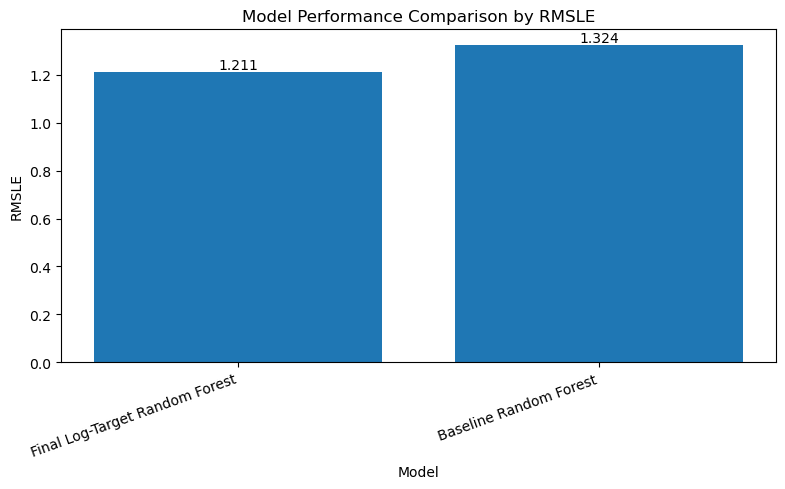

Model comparison plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/model_comparison.png


In [84]:
# ==========================================
# 17. Model Comparison Plot
# ==========================================

results_summary = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Final Log-Target Random Forest"
    ],
    "RMSLE": [
        float(baseline_rmsle),
        float(final_rf_rmsle)
    ],
    "Training Time Seconds": [
        round(float(baseline_training_time), 1),
        round(float(final_training_time), 1)
    ]
})

results_summary = results_summary.sort_values("RMSLE").reset_index(drop=True)

print("Final model comparison:")
display(results_summary)

best_model_name = results_summary.loc[0, "Model"]
best_model_rmsle = results_summary.loc[0, "RMSLE"]

print("Best model:", best_model_name)
print(f"Best RMSLE: {best_model_rmsle:.5f}")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_summary["Model"],
    results_summary["RMSLE"]
)

plt.xlabel("Model")
plt.ylabel("RMSLE")
plt.title("Model Performance Comparison by RMSLE")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, results_summary["RMSLE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plot_path = SCREENSHOT_DIR / "model_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Model comparison plot saved to:", plot_path)

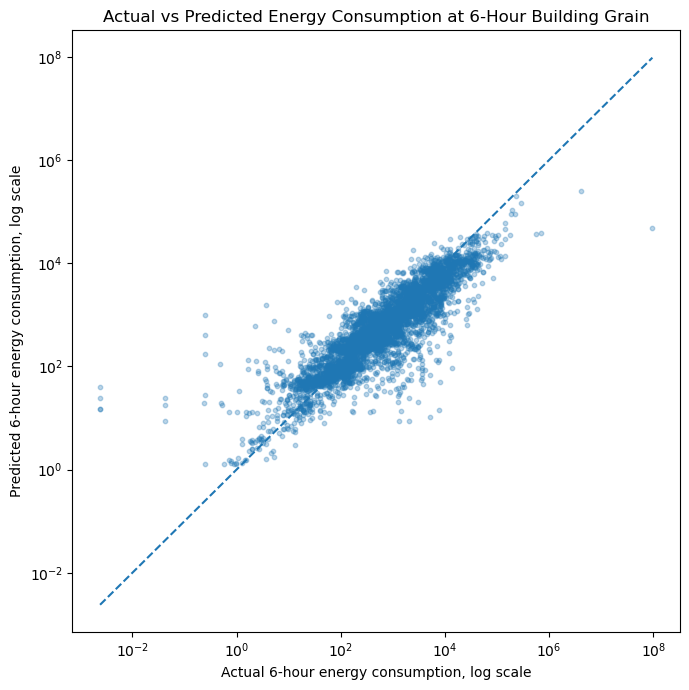

Actual-vs-predicted plot saved to: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/actual_vs_predicted_6h.png


In [85]:
# ==========================================
# 18. Actual vs Predicted Plot at Correct Grain
# ==========================================

prediction_plot_df = (
    final_rf_pred
    .filter(F.col("actual_consumption") > 0)
    .filter(F.col("predicted_consumption") > 0)
    .sample(False, 0.20, seed=42)
    .limit(10000)
    .toPandas()
)

plt.figure(figsize=(7, 7))
plt.scatter(
    prediction_plot_df["actual_consumption"],
    prediction_plot_df["predicted_consumption"],
    alpha=0.3,
    s=10
)

min_value = min(
    prediction_plot_df["actual_consumption"].min(),
    prediction_plot_df["predicted_consumption"].min()
)
max_value = max(
    prediction_plot_df["actual_consumption"].max(),
    prediction_plot_df["predicted_consumption"].max()
)

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual 6-hour energy consumption, log scale")
plt.ylabel("Predicted 6-hour energy consumption, log scale")
plt.title("Actual vs Predicted Energy Consumption at 6-Hour Building Grain")
plt.tight_layout()

plot_path = SCREENSHOT_DIR / "actual_vs_predicted_6h.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Actual-vs-predicted plot saved to:", plot_path)

In [86]:
# ==========================================
# 19. Error Summary at Correct Grain
# ==========================================

error_summary = (
    final_rf_pred
    .withColumn("absolute_error", F.abs(F.col("predicted_consumption") - F.col("actual_consumption")))
    .withColumn(
        "squared_log_error",
        F.pow(F.col("prediction_log") - F.col("log_consumption_6h"), 2)
    )
    .agg(
        F.count("*").alias("rows"),
        F.mean("actual_consumption").alias("mean_actual_consumption"),
        F.mean("predicted_consumption").alias("mean_predicted_consumption"),
        F.mean("absolute_error").alias("mean_absolute_error"),
        F.sqrt(F.mean("squared_log_error")).alias("rmsle")
    )
    .toPandas()
)

print("Error summary at building + 6-hour grain:")
display(error_summary)

Error summary at building + 6-hour grain:


,rows,mean_actual_consumption,mean_predicted_consumption,mean_absolute_error,rmsle
0,28450,18936.956194,2192.762649,17240.618105,1.211208


## 17. Save final model and metadata

The final Spark ML pipeline is saved to the `models/` directory so it can be reused by the streaming prediction notebook. Saving the full pipeline preserves the preprocessing stages as well as the trained Random Forest model.

A separate metadata file records the target transformation, feature list, model settings and final evaluation score. This makes the modelling artifact easier to audit and explain in a project review.



In [88]:
# ==========================================
# 20. Save Final Model
# ==========================================

MODEL_PATH = MODEL_DIR / "final_random_forest_model"

if MODEL_PATH.exists():
    shutil.rmtree(MODEL_PATH)

final_rf_model.write().overwrite().save(str(MODEL_PATH))

print("Final model saved successfully.")
print("Model path:", MODEL_PATH)

Final model saved successfully.
Model path: /Users/harshithreddy/building-energy-prediction-streaming/models/final_random_forest_model


In [89]:
# ==========================================
# 21. Save Model Metadata
# ==========================================

model_metadata = {
    "model_name": "Final Log-Target Random Forest",
    "target": "log_consumption_6h",
    "target_transformation": "log1p(consumption_6h)",
    "prediction_inverse_transformation": "expm1(prediction)",
    "model_grain": "site_id + building_id + 6-hour window",
    "rmsle": float(final_rf_rmsle),
    "sample_fraction": SAMPLE_FRACTION,
    "num_trees": FINAL_NUM_TREES,
    "max_depth": FINAL_MAX_DEPTH,
    "max_bins": FINAL_MAX_BINS,
    "categorical_features": categorical_cols,
    "numeric_features": numeric_cols,
    "screenshots": {
        "log_distribution": str(SCREENSHOT_DIR / "eda_log_consumption_distribution.png"),
        "six_hour_block": str(SCREENSHOT_DIR / "eda_consumption_by_6h_block.png"),
        "primary_use": str(SCREENSHOT_DIR / "eda_consumption_by_primary_use.png"),
        "building_size": str(SCREENSHOT_DIR / "eda_building_size_vs_consumption.png"),
        "temperature": str(SCREENSHOT_DIR / "eda_temperature_vs_consumption.png"),
        "model_comparison": str(SCREENSHOT_DIR / "model_comparison.png"),
        "actual_vs_predicted": str(SCREENSHOT_DIR / "actual_vs_predicted_6h.png")
    }
}

metadata_path = MODEL_DIR / "model_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Model metadata saved.")
print("Metadata path:", metadata_path)
print(json.dumps(model_metadata, indent=4))

Model metadata saved.
Metadata path: /Users/harshithreddy/building-energy-prediction-streaming/models/model_metadata.json
{
    "model_name": "Final Log-Target Random Forest",
    "target": "log_consumption_6h",
    "target_transformation": "log1p(consumption_6h)",
    "prediction_inverse_transformation": "expm1(prediction)",
    "model_grain": "site_id + building_id + 6-hour window",
    "rmsle": 1.2112076380234043,
    "sample_fraction": 0.1,
    "num_trees": 80,
    "max_depth": 12,
    "max_bins": 32,
    "categorical_features": [
        "primary_use",
        "season_flag"
    ],
    "numeric_features": [
        "log_square_feet",
        "floor_count",
        "building_age",
        "air_temperature_6h",
        "dew_temperature_6h",
        "sea_level_pressure_6h",
        "wind_speed_6h",
        "cloud_coverage_6h",
        "wind_dir_sin",
        "wind_dir_cos",
        "latent_y",
        "latent_s",
        "latent_r"
    ],
    "screenshots": {
        "log_distribution

## 18. Final notebook check

The final checkpoint confirms that the model, metadata and evaluation outputs were produced successfully. It also prints the exact feature list expected by the streaming prediction notebook.

After this point, the batch modelling stage is complete and the project can move to real-time prediction using Kafka and Spark Structured Streaming.



In [91]:
# ==========================================
# 22. Final Notebook Check
# ==========================================

print("Batch model notebook completed successfully.")
print("Saved model path:", MODEL_DIR / "final_random_forest_model")
print("Saved metadata path:", MODEL_DIR / "model_metadata.json")
print(f"Final RMSLE: {final_rf_rmsle:.5f}")

print("\nFeature columns used by model:")
for col_name in categorical_cols + numeric_cols:
    print("-", col_name)



Batch model notebook completed successfully.
Saved model path: /Users/harshithreddy/building-energy-prediction-streaming/models/final_random_forest_model
Saved metadata path: /Users/harshithreddy/building-energy-prediction-streaming/models/model_metadata.json
Final RMSLE: 1.21121

Feature columns used by model:
- primary_use
- season_flag
- log_square_feet
- floor_count
- building_age
- air_temperature_6h
- dew_temperature_6h
- sea_level_pressure_6h
- wind_speed_6h
- cloud_coverage_6h
- wind_dir_sin
- wind_dir_cos
- latent_y
- latent_s
- latent_r
